In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve )
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../datasets/alzheimers_disease_data.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid


In [3]:
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
configs = {

    "Config 1\n(Default RF)": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Config 2\n(300 Trees)": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Config 3\n(Depth=5)": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),

    "Config 4\n(Depth=20)": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42
    ),

    "Config 5\n(Balanced)": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
}

In [5]:
results = []

for config_name, model in configs.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test,y_pred)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']

    auc = roc_auc_score(y_test,y_prob)

    results.append({

        'Config':config_name,
        'Accuracy':acc,
        'Precision':precision,
        'Recall':recall,
        'F1-Score':f1,
        'ROC-AUC':auc,

        '_model':model,
        '_y_pred':y_pred,
        '_y_prob':y_prob

    })

results_df = pd.DataFrame(results)

results_df

,Config,Accuracy,Precision,Recall,F1-Score,ROC-AUC,_model,_y_pred,_y_prob
0,Config 1\n(Default RF),0.937209,0.937063,0.881579,0.908475,0.939038,"(DecisionTreeClassifier(max_features='sqrt', r...","[1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, ...","[0.79, 0.13, 0.68, 0.47, 0.85, 0.07, 0.63, 0.0..."
1,Config 2\n(300 Trees),0.948837,0.945205,0.907895,0.926174,0.939985,"(DecisionTreeClassifier(max_features='sqrt', r...","[1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, ...","[0.79, 0.15333333333333332, 0.69, 0.4533333333..."
2,Config 3\n(Depth=5),0.897674,0.942623,0.756579,0.839416,0.938731,"(DecisionTreeClassifier(max_depth=5, max_featu...","[1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, ...","[0.5995847600259052, 0.2946494828149266, 0.582..."
3,Config 4\n(Depth=20),0.934884,0.936620,0.875000,0.904762,0.939157,"(DecisionTreeClassifier(max_depth=20, max_feat...","[1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, ...","[0.79, 0.13, 0.67, 0.47, 0.84, 0.07, 0.62, 0.0..."
4,Config 5\n(Balanced),0.951163,0.945578,0.914474,0.929766,0.937358,"(DecisionTreeClassifier(max_features='sqrt', r...","[1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, ...","[0.87, 0.18, 0.84, 0.56, 0.94, 0.16, 0.73, 0.1..."


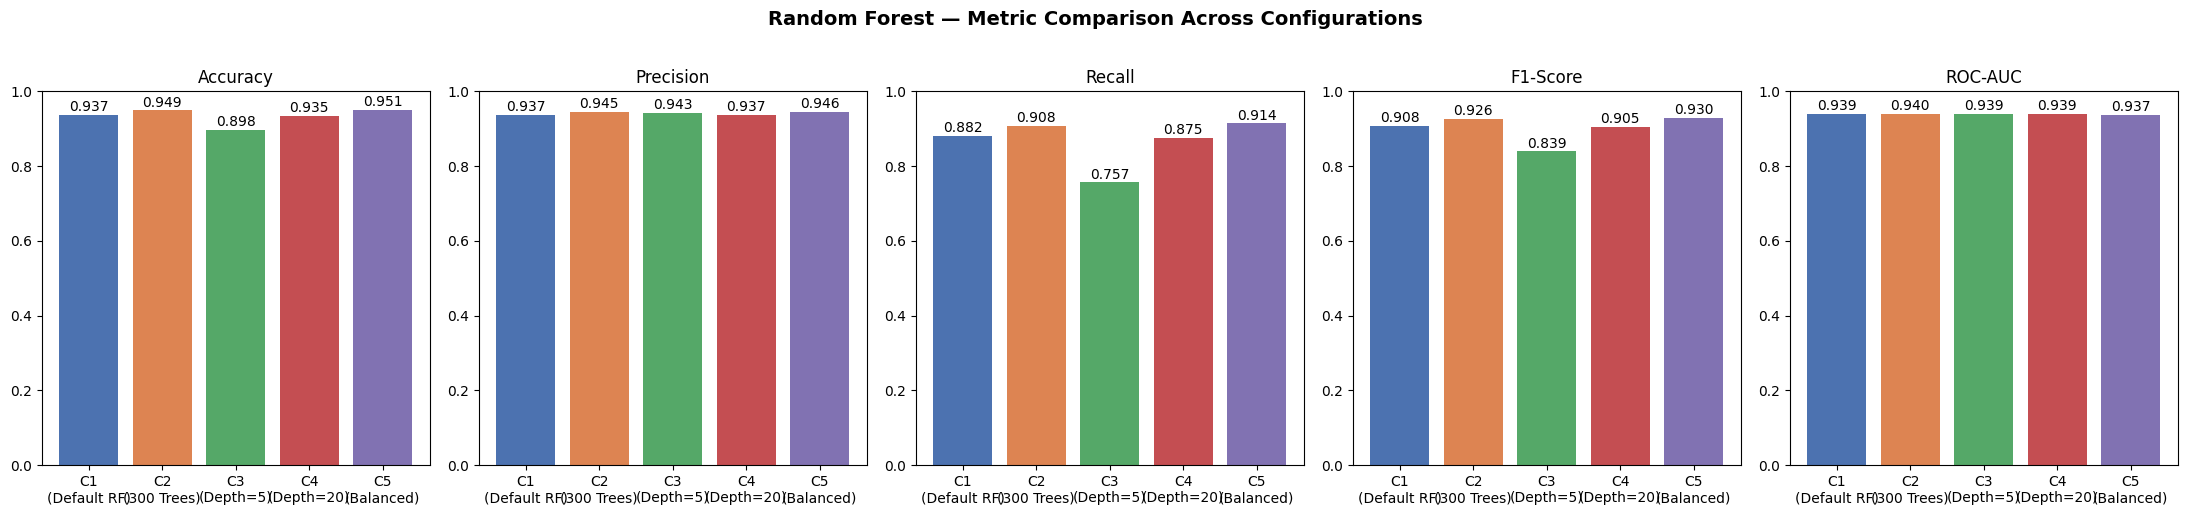

In [6]:
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
config_labels = [r['Config'].replace('Config ','C') for r in results]
fig, axes = plt.subplots(1,5,figsize=(22,5))
fig.suptitle( 'Random Forest — Metric Comparison Across Configurations', fontsize=14, fontweight='bold', y=1.02 )
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
for i, metric in enumerate(metrics):
  vals = [r[metric] for r in results]
  bars = axes[i].bar(config_labels, vals, color=colors )
  axes[i].set_title(metric)
  axes[i].set_ylim(0,1)
  for bar,val in zip(bars,vals):
    axes[i].text( bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center' )
plt.tight_layout()
plt.show()

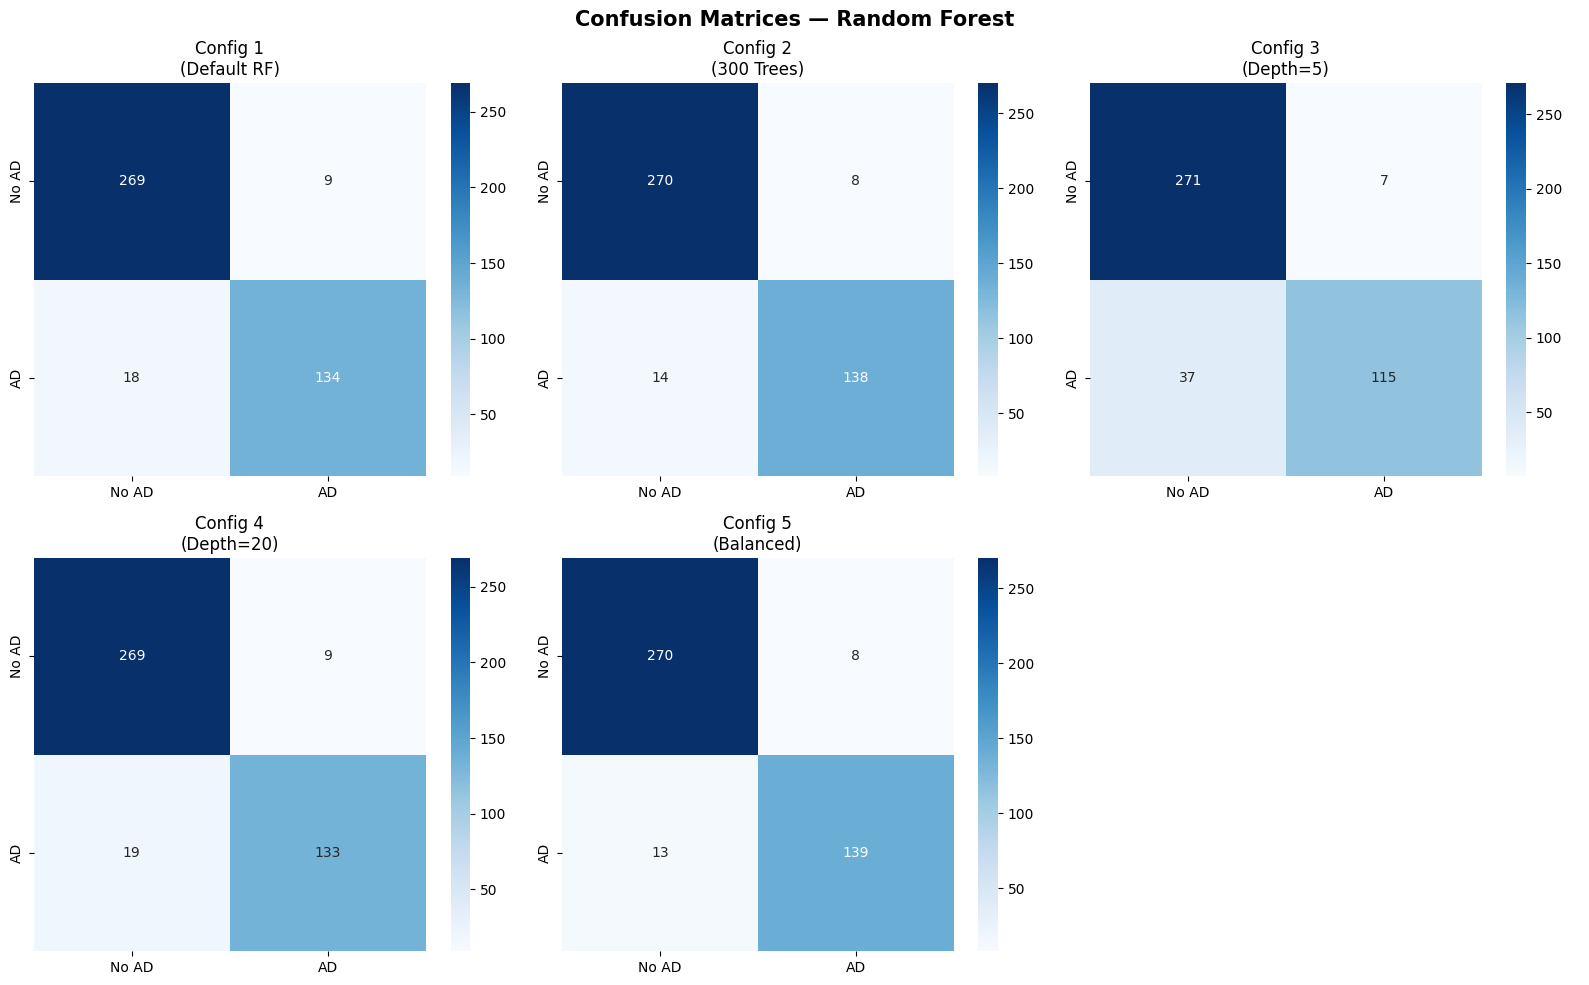

In [7]:
fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()
for i,r in enumerate(results):
  cm = confusion_matrix( y_test, r['_y_pred'] )
  sns.heatmap( cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=['No AD','AD'], yticklabels=['No AD','AD'] )
  axes[i].set_title(r['Config'])
  axes[-1].axis('off')
  plt.suptitle( 'Confusion Matrices — Random Forest', fontsize=15, fontweight='bold' )
plt.tight_layout()
plt.show()

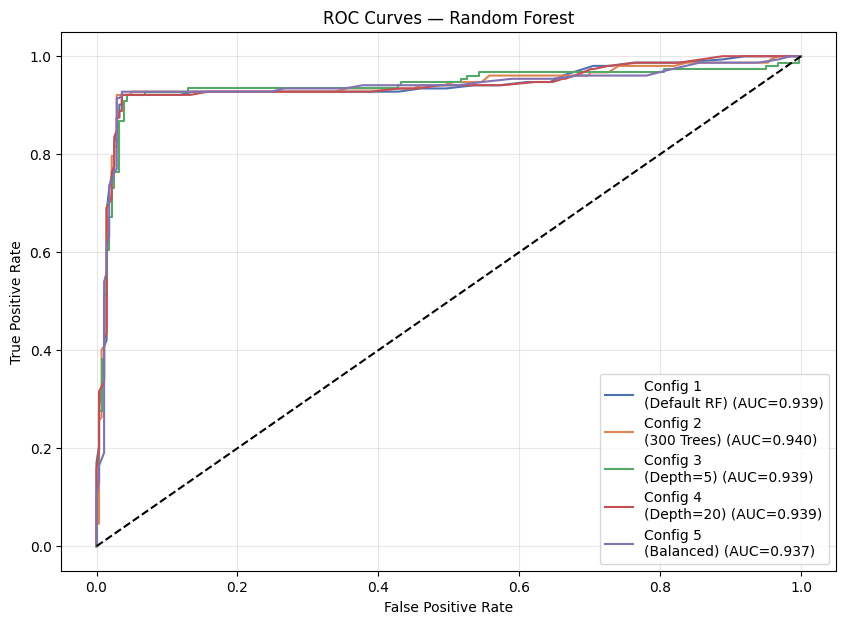

In [8]:
plt.figure(figsize=(10,7))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
for i,r in enumerate(results):
  fpr,tpr,_ = roc_curve( y_test, r['_y_prob'] )
  plt.plot( fpr, tpr, label=f"{r['Config']} (AUC={r['ROC-AUC']:.3f})", color=colors[i] )
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Best Config: Config 2
(300 Trees) | ROC-AUC: 0.9400


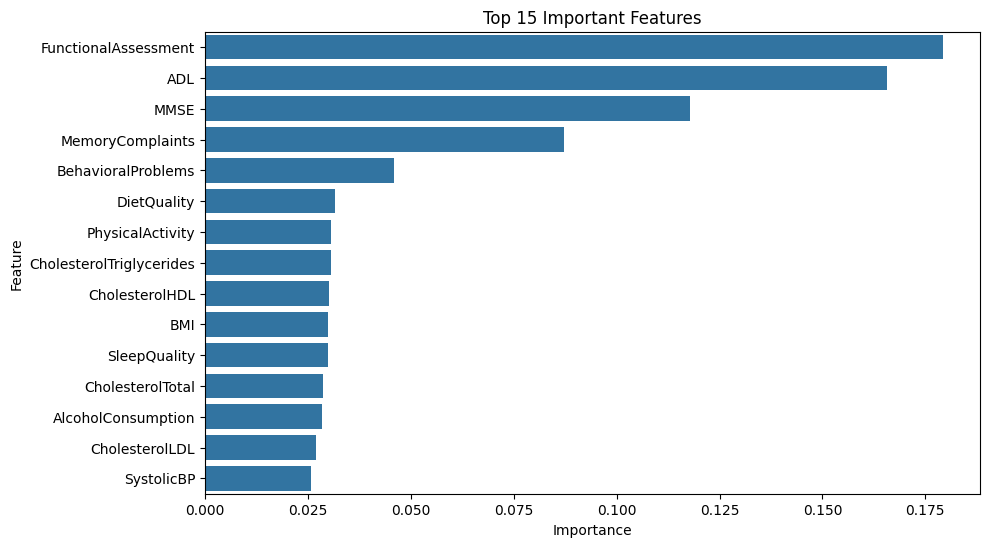

In [9]:
best = max( results, key=lambda r:r['ROC-AUC'] )
print( f"Best Config: {best['Config']} | ROC-AUC: {best['ROC-AUC']:.4f}" )
model_best = best['_model']
importance_df = pd.DataFrame({ 'Feature': X.columns, 'Importance': model_best.feature_importances_ })
importance_df = importance_df.sort_values( 'Importance', ascending=False ).head(15)
plt.figure(figsize=(10,6))
sns.barplot( data=importance_df, x='Importance', y='Feature' )
plt.title('Top 15 Important Features')
plt.show()

In [10]:
print("="*75)
print("FINAL SUMMARY — RANDOM FOREST CONFIGURATIONS")
print("="*75)
ranked = results_df.drop( columns=['_model','_y_pred','_y_prob'] ).sort_values( 'ROC-AUC', ascending=False )
print(ranked.to_string(index=False))
print( "\nBest ROC-AUC:", ranked.iloc[0]['Config'] )
print( "Best Accuracy:", ranked.loc[ ranked['Accuracy'].idxmax(), 'Config' ] )

FINAL SUMMARY — RANDOM FOREST CONFIGURATIONS
                Config  Accuracy  Precision   Recall  F1-Score  ROC-AUC
 Config 2\n(300 Trees)  0.948837   0.945205 0.907895  0.926174 0.939985
  Config 4\n(Depth=20)  0.934884   0.936620 0.875000  0.904762 0.939157
Config 1\n(Default RF)  0.937209   0.937063 0.881579  0.908475 0.939038
   Config 3\n(Depth=5)  0.897674   0.942623 0.756579  0.839416 0.938731
  Config 5\n(Balanced)  0.951163   0.945578 0.914474  0.929766 0.937358

Best ROC-AUC: Config 2
(300 Trees)
Best Accuracy: Config 5
(Balanced)


In [11]:
from joblib import dump

dump(model, '../trained_models/random_forest.pkl')

['../trained_models/random_forest.pkl']